# Term Document Matrix

How do we represent a document as a vector? A collection of such vectors is known as a "Term Document Matrix" (TDM).

In [1]:
from google.colab import drive
drive.mount('/content/drive')  # Add My Drive/<>

import os
os.chdir('drive/My Drive')
os.chdir('Books_Writings/NLPBook/')

Mounted at /content/drive


In [2]:
%%capture
%pylab inline
import pandas as pd
import os
# !pip install ipypublish
# from ipypublish import nb_setup
%load_ext rpy2.ipython
from IPython.display import Image

## Term Document Matrix

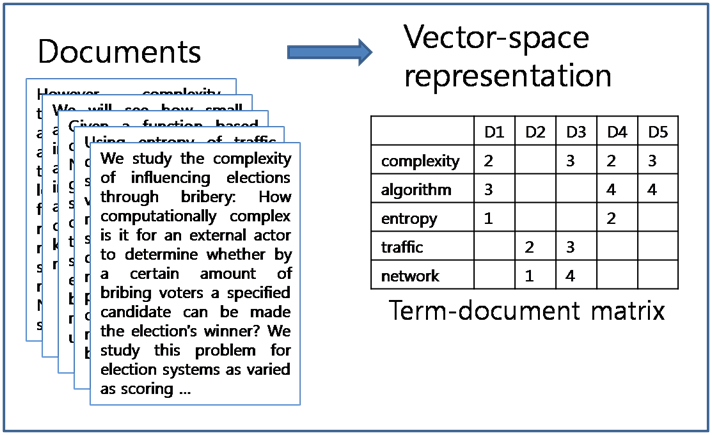

In [ ]:
Image("NLP_images/tdm.png", width=500)

## Term Frequency - Inverse Document Frequency (TF-IDF)

This is a weighting scheme provided to sharpen the importance of rare words in a document, relative to the frequency of these words in the corpus. It is based on simple calculations and even though it does not have strong theoretical foundations, it is still very useful in practice. The TF-IDF is the importance of a word $w$ in a document $d$ in a corpus $C$. Therefore it is a function of all these three, i.e., we write it as $TFIDF(w,d,C)$, and is the product of term frequency (TF) and inverse document frequency (IDF).

The frequency of a word in a document is defined as

$$
f(w,d)=\frac{\#w \in d}{|d|}
$$

where $|d|$ is the number of words in the document. We may normalize word frequency so that

$$
TF(w,d)=ln[f(w,d)]
$$

This is log normalization. Another form of normalization is known as double normalization and is as follows:

$$
TF(w,d)=\frac{1}{2} + \frac{1}{2} \cdot \frac{f(w,d)}{\max_{w \in d} f(w,d)}
$$

Note that normalization is not necessary, but it tends to help shrink the difference between counts of words.

Inverse document frequency is as follows (in this case we show the normalized version):

$$
IDF(w,C)=\ln\left[\frac{|C|}{|d_{w \in d}|}\right]
$$

That is, we compute the ratio of the number of documents in the corpus $C$ divided by the number of documents with word $w$ in the corpus.

Finally, we have the weighting score for a given word $w$ in document $d$ in corpus $C$:

$$
TFIDF(w,d,C)=TF(w,d) \times IDF(w,C)
$$

In [3]:
# Collect some text data
!pip install cssselect
import requests
from lxml.html import fromstring

#Copy the URL from the web site
url = 'https://economictimes.indiatimes.com'
html = requests.get(url, timeout=10).text

#See: http://infohost.nmt.edu/~shipman/soft/pylxml/web/etree-fromstring.html
doc = fromstring(html)

#http://lxml.de/cssselect.html#the-cssselect-method
x = doc.cssselect(".jsx-48c379259a10063f")
print(len(x))

headlines = [j.text_content() for j in x]
headlines = [j for j in headlines if len(j)>20]
headlines = unique(headlines)
headlines = headlines[:20]   #Needed to exclude any other stuff that was not needed.
print(headlines)

50
["'EV prices to match petrol cars in 4-6 months'"
 'Bihar: NDA, Mahagathbandhan & Jan Suraaj'
 'Climate-linked insurance schemes soon?'
 'DGCA probes Air India Birmingham incident'
 'Eli Lilly to invest over $1 billion in India'
 'Festive season spending may hit Rs 14L crore'
 "France's new prime minister resigns"
 'If Trumpâ\x80\x99s tariffs are illegal, expect chaos'
 'Indiaâ\x80\x99s multilingual AI model for the world'
 'Inside India Incâ\x80\x99s big GenAI gambit'
 "Inside India Incâ\x80\x99s big GenAI gambitNeed AI friend? They are just a click awayRealty uses fake PANs to dodge taxBihar: NDA, Mahagathbandhan & Jan SuraajLTIMindtree wins its largest-ever dealSC directs RBI, SEBI, IRDAI to track Rs 3.5L crMercedes-Benz records best-ever Sept salesUS federal shutdown enters 6th dayIf Trumpâ\x80\x99s tariffs are illegal, expect chaos'EV prices to match petrol cars in 4-6 months'Mahindra launches new Bolero rangePower regulator reviews solar delay lossesTata Turmoil: Infighting tr

In the next code block, we see the use of Scikit-Learn's TFIDF vectorizer. We have 20 headlines (documents) and the dimension of the matrix will be 20 times the number of unique words (terms) across all the documents. The dimension is shown in the output below. From the dimensions we see that it is a document-term matrix (DTM) and its transpose will be a TDM.

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
tfidf = TfidfVectorizer()
# tfidf = CountVectorizer()
tfs = tfidf.fit_transform(headlines)
tfs

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 364 stored elements and shape (20, 147)>

In [5]:
print(tfidf.get_feature_names_out())

['14l' '5l' '6th' 'again' 'agr' 'ai' 'air' 'are' 'away' 'awayrealty' 'be'
 'benz' 'best' 'big' 'bihar' 'billion' 'birmingham' 'bolero' 'cars'
 'chaos' 'click' 'climate' 'court' 'cr' 'crisis' 'crmercedes' 'crore'
 'crorefrance' 'dayif' 'deal' 'dealsc' 'defers' 'delay' 'dgca' 'directs'
 'dodge' 'dues' 'eli' 'enters' 'ev' 'ever' 'expect' 'fake' 'federal'
 'festive' 'for' 'france' 'friend' 'from' 'gambit' 'gambitneed' 'genai'
 'govt' 'hit' 'if' 'illegal' 'in' 'incident' 'incidenttrump' 'incâ'
 'india' 'indiadgca' 'indiaâ' 'infighting' 'inside' 'insurance' 'invest'
 'irdai' 'is' 'its' 'jan' 'just' 'largest' 'launches' 'lilly' 'linked'
 'losses' 'lossestata' 'ltimindtree' 'mahagathbandhan' 'mahindra' 'match'
 'may' 'mercedes' 'minister' 'mired' 'model' 'months' 'more'
 'multilingual' 'nda' 'need' 'new' 'news' 'over' 'pans' 'petrol' 'plea'
 'pleafestive' 'political' 'power' 'powers' 'prices' 'prime' 'probes'
 'put' 'range' 'rangepower' 'rbi' 'realty' 'records' 'regulator' 'resigns'
 'resignse

In [6]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize
res = [word_tokenize(j) for j in headlines]
res[:2]

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


[["'EV",
  'prices',
  'to',
  'match',
  'petrol',
  'cars',
  'in',
  '4-6',
  'months',
  "'"],
 ['Bihar', ':', 'NDA', ',', 'Mahagathbandhan', '&', 'Jan', 'Suraaj']]

In [7]:
# Make TDM
tdm_mat = tfs.toarray().T
print(tdm_mat.shape)
tdm_mat

(147, 20)


array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.3179639 ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.34444564,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

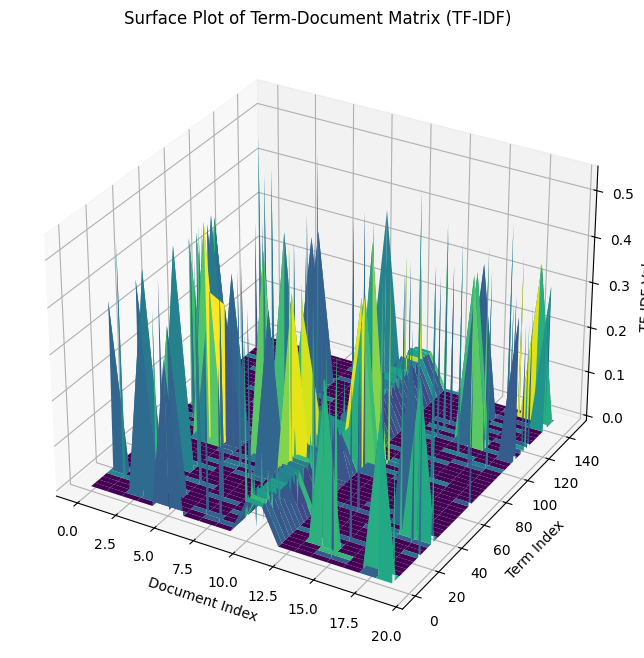

In [8]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

x = np.arange(tdm_mat.shape[1])
y = np.arange(tdm_mat.shape[0])
X, Y = np.meshgrid(x, y)
Z = tdm_mat

ax.plot_surface(X, Y, Z, cmap='viridis')

ax.set_xlabel('Document Index')
ax.set_ylabel('Term Index')
ax.set_zlabel('TF-IDF Value')
ax.set_title('Surface Plot of Term-Document Matrix (TF-IDF)')

plt.show()

## The BM25 Algorithm

- This is a modification of TF-IDF to account for word saturation and document length. See: https://zilliz.com/learn/mastering-bm25-a-deep-dive-into-the-algorithm-and-application-in-milvus

- A HuggingFace implementation: https://huggingface.co/blog/xhluca/bm25s

Both, the TF and IDF parts are modified as follows:

$$
TF(w,d) = \frac{TF(w,d)}{TF(w,d) + k (1-b+b \cdot \frac{|d|}{AVG(|d|)})}
$$

where $k$ modulates word saturation and $b$ modulates document length. The size of document $d$ is denoted as $|d|$.

$$
IDF(w) = \ln\left[\frac{|C|-DF(w)+0.5}{DF(w)+0.5} \right], \quad \mbox{if } DF(w)\geq 0.5
$$

else

$$
IDF(w) = \ln \left[\frac{|C|}{DF(w)} \right], \quad \mbox{if } DF(w) < 0.5
$$

where $N$ is the number of documents and $DF(w)$ is the document frequency for word $w$.

## Implementation of BM25

- Ref: https://gist.github.com/koreyou/f3a8a0470d32aa56b32f198f49a9f2b8
- Another reference: https://pypi.org/project/rank-bm25/
- Notebook: https://colab.research.google.com/github/pinecone-io/examples/blob/master/learn/search/semantic-search/sparse/bm25/bm25-vector-generation.ipynb

## WordClouds

We can take the text in the headlines and generate a wordcloud.

In [ ]:
# !conda install -c conda-forge wordcloud -y

In [9]:
text = ''
for h in headlines:
    text = text + ' ' + h
print(text)

 'EV prices to match petrol cars in 4-6 months' Bihar: NDA, Mahagathbandhan & Jan Suraaj Climate-linked insurance schemes soon? DGCA probes Air India Birmingham incident Eli Lilly to invest over $1 billion in India Festive season spending may hit Rs 14L crore France's new prime minister resigns If Trumpâs tariffs are illegal, expect chaos Indiaâs multilingual AI model for the world Inside India Incâs big GenAI gambit Inside India Incâs big GenAI gambitNeed AI friend? They are just a click awayRealty uses fake PANs to dodge taxBihar: NDA, Mahagathbandhan & Jan SuraajLTIMindtree wins its largest-ever dealSC directs RBI, SEBI, IRDAI to track Rs 3.5L crMercedes-Benz records best-ever Sept salesUS federal shutdown enters 6th dayIf Trumpâs tariffs are illegal, expect chaos'EV prices to match petrol cars in 4-6 months'Mahindra launches new Bolero rangePower regulator reviews solar delay lossesTata Turmoil: Infighting triggers govt talksWhy is France mired in political crisis?Climate

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

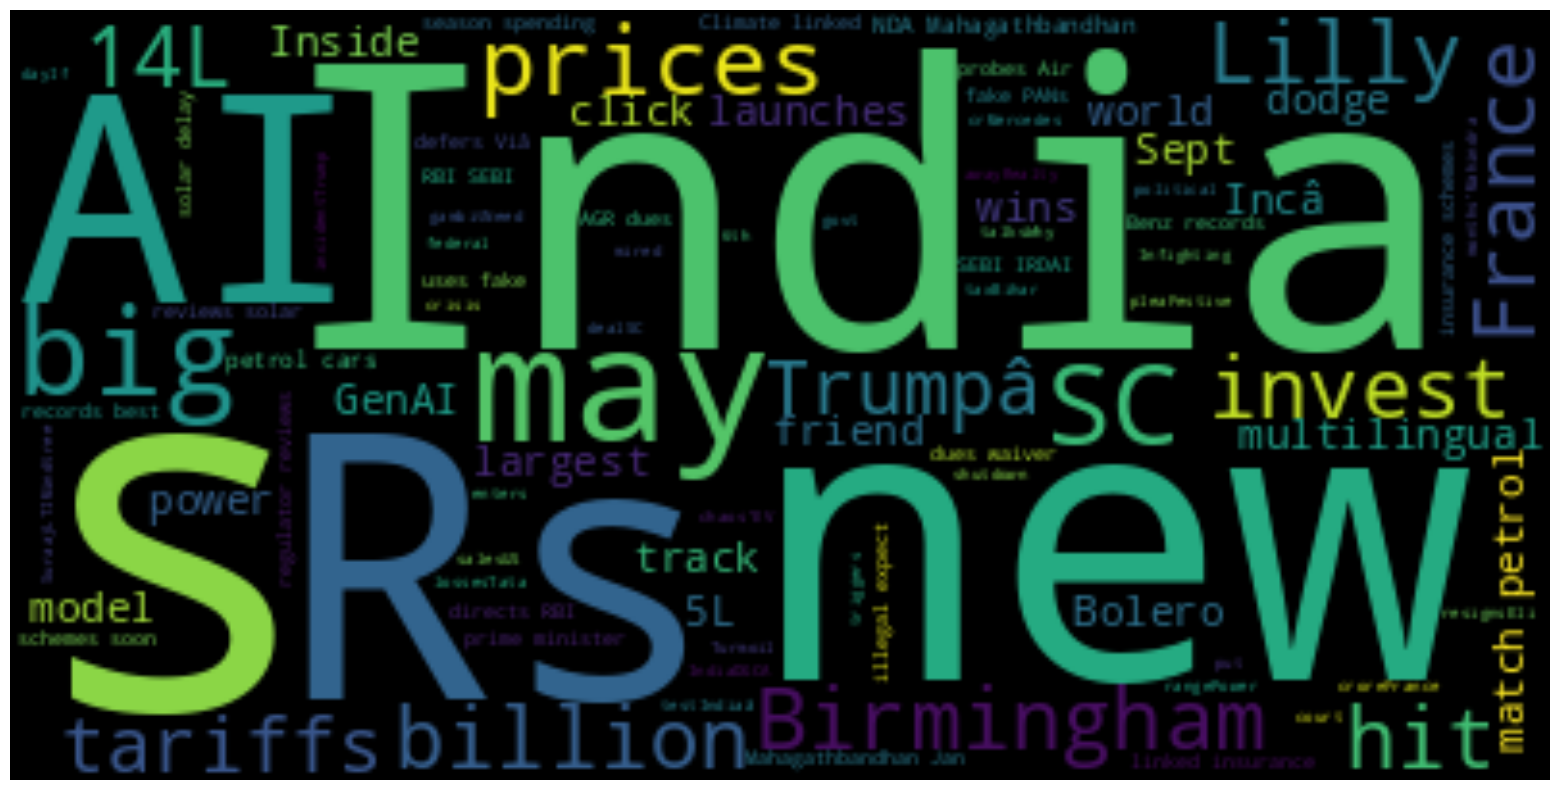

In [10]:
from wordcloud import WordCloud
wordcloud = WordCloud().generate(text)

#Use pyplot from matplotlib
figure(figsize=(20,10))
pyplot.imshow(wordcloud, interpolation='bilinear')
pyplot.axis("off")